<a href="https://colab.research.google.com/github/anshika153/crop_yield_prediction_MLproject/blob/main/crop_yield_prediction_ML_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Section 1- Import Libraries

In [121]:
import warnings
warnings.filterwarnings("ignore")

In [122]:
import numpy as np
import pandas as pd

In [123]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

In [124]:
from sklearn.model_selection import train_test_split

In [125]:
from sklearn.preprocessing import LabelEncoder

In [126]:
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)

In [127]:
import joblib

# Section 2- Load the datasets

In [128]:
crop = pd.read_csv("/crop_yield.csv")
weather = pd.read_csv("/weather_data.csv")
soil = pd.read_csv("/soil_data.csv")

In [129]:
print("Crop Dataset :", crop.shape)
print("Weather Dataset :", weather.shape)
print("Soil Dataset :", soil.shape)

Crop Dataset : (19689, 9)
Weather Dataset : (720, 5)
Soil Dataset : (30, 5)


# Section 3 — Dataset Exploration

In [130]:
crop.head()

,Crop,Crop_Year,Season,State,Area,Production,Fertilizer,Pesticide,Yield
0,Arecanut,1997,Whole Year,Assam,73814.0,56708,7024878.38,22882.34,0.796087
1,Arhar/Tur,1997,Kharif,Assam,6637.0,4685,631643.29,2057.47,0.710435
2,Castor seed,1997,Kharif,Assam,796.0,22,75755.32,246.76,0.238333
3,Coconut,1997,Whole Year,Assam,19656.0,126905000,1870661.52,6093.36,5238.051739
4,Cotton(lint),1997,Kharif,Assam,1739.0,794,165500.63,539.09,0.420909


In [131]:
weather.head()

,state,year,avg_temp_c,total_rainfall_mm,avg_humidity_percent
0,Andhra Pradesh,1997,28.21,1191.08,69.56
1,Andhra Pradesh,1998,28.21,1100.41,71.95
2,Andhra Pradesh,1999,28.03,603.67,66.91
3,Andhra Pradesh,2000,27.74,1070.25,70.73
4,Andhra Pradesh,2001,28.08,910.13,68.69


In [132]:
soil.head()

,state,N,P,K,pH
0,Andhra Pradesh,78,45,22,6.8
1,Arunachal Pradesh,55,15,35,5.5
2,Assam,60,18,38,5.8
3,Bihar,85,30,25,7.2
4,Chhattisgarh,70,35,20,6.5


In [133]:
crop.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19689 entries, 0 to 19688
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Crop        19689 non-null  object 
 1   Crop_Year   19689 non-null  int64  
 2   Season      19689 non-null  object 
 3   State       19689 non-null  object 
 4   Area        19689 non-null  float64
 5   Production  19689 non-null  int64  
 6   Fertilizer  19689 non-null  float64
 7   Pesticide   19689 non-null  float64
 8   Yield       19689 non-null  float64
dtypes: float64(4), int64(2), object(3)
memory usage: 1.4+ MB


In [134]:
weather.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 720 entries, 0 to 719
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   state                 720 non-null    object 
 1   year                  720 non-null    int64  
 2   avg_temp_c            720 non-null    float64
 3   total_rainfall_mm     720 non-null    float64
 4   avg_humidity_percent  720 non-null    float64
dtypes: float64(3), int64(1), object(1)
memory usage: 28.3+ KB


In [135]:
soil.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   state   30 non-null     object 
 1   N       30 non-null     int64  
 2   P       30 non-null     int64  
 3   K       30 non-null     int64  
 4   pH      30 non-null     float64
dtypes: float64(1), int64(3), object(1)
memory usage: 1.3+ KB


In [136]:
crop.describe()

,Crop_Year,Area,Production,Fertilizer,Pesticide,Yield
count,19689.000000,1.968900e+04,1.968900e+04,1.968900e+04,1.968900e+04,19689.000000
mean,2009.127584,1.799266e+05,1.643594e+07,2.410331e+07,4.884835e+04,79.954009
std,6.498099,7.328287e+05,2.630568e+08,9.494600e+07,2.132874e+05,878.306193
min,1997.000000,5.000000e-01,0.000000e+00,5.417000e+01,9.000000e-02,0.000000
25%,2004.000000,1.390000e+03,1.393000e+03,1.880146e+05,3.567000e+02,0.600000
50%,2010.000000,9.317000e+03,1.380400e+04,1.234957e+06,2.421900e+03,1.030000
75%,2015.000000,7.511200e+04,1.227180e+05,1.000385e+07,2.004170e+04,2.388889
max,2020.000000,5.080810e+07,6.326000e+09,4.835407e+09,1.575051e+07,21105.000000


In [137]:
weather.describe()

,year,avg_temp_c,total_rainfall_mm,avg_humidity_percent
count,720.000000,720.000000,720.000000,720.000000
mean,2008.500000,23.383389,1388.461083,64.825764
std,6.926999,4.968676,672.503842,12.148615
min,1997.000000,6.260000,249.240000,34.470000
25%,2002.750000,22.265000,914.985000,54.615000
50%,2008.500000,25.115000,1231.830000,68.710000
75%,2014.250000,26.580000,1702.595000,74.567500
max,2020.000000,28.630000,5363.280000,86.060000


In [138]:
soil.describe()

,N,P,K,pH
count,30.000000,30.000000,30.000000,30.000000
mean,75.566667,31.466667,33.333333,6.553333
std,22.730328,12.386682,7.594614,0.763717
min,50.000000,15.000000,20.000000,5.500000
25%,60.500000,20.000000,28.500000,5.900000
50%,70.000000,29.000000,34.500000,6.450000
75%,80.000000,41.500000,38.000000,7.075000
max,150.000000,55.000000,50.000000,8.000000


In [139]:
crop.isnull().sum()

,0
Crop,0
Crop_Year,0
Season,0
State,0
Area,0
Production,0
Fertilizer,0
Pesticide,0
Yield,0


In [140]:
weather.isnull().sum()

,0
state,0
year,0
avg_temp_c,0
total_rainfall_mm,0
avg_humidity_percent,0


In [141]:
soil.isnull().sum()

,0
state,0
N,0
P,0
K,0
pH,0


# Section 4 – Dataset Merging

In [142]:
crop.rename(columns={
    "State": "state",
    "Crop_Year": "year"
}, inplace=True)

In [143]:
print(crop.columns)
print(weather.columns)
print(soil.columns)

Index(['Crop', 'year', 'Season', 'state', 'Area', 'Production', 'Fertilizer',
       'Pesticide', 'Yield'],
      dtype='object')
Index(['state', 'year', 'avg_temp_c', 'total_rainfall_mm',
       'avg_humidity_percent'],
      dtype='object')
Index(['state', 'N', 'P', 'K', 'pH'], dtype='object')


In [144]:
merged = crop.merge(
    weather,
    on=["state", "year"],
    how="left"
)

In [145]:
merged = merged.merge(
    soil,
    on="state",
    how="left"
)

In [146]:
merged["Crop"] = merged["Crop"].str.strip()
merged["Season"] = merged["Season"].str.strip()
merged["state"] = merged["state"].str.strip()

merged["Crop"] = merged["Crop"].str.replace(r"\s+", " ", regex=True)
merged["Season"] = merged["Season"].str.replace(r"\s+", " ", regex=True)
merged["state"] = merged["state"].str.replace(r"\s+", " ", regex=True)

In [147]:
print("Merged Dataset Shape:", merged.shape)

Merged Dataset Shape: (19689, 16)


In [148]:
merged.head()

,Crop,year,Season,state,Area,Production,Fertilizer,Pesticide,Yield,avg_temp_c,total_rainfall_mm,avg_humidity_percent,N,P,K,pH
0,Arecanut,1997,Whole Year,Assam,73814.0,56708,7024878.38,22882.34,0.796087,22.41,1468.92,70.71,60,18,38,5.8
1,Arhar/Tur,1997,Kharif,Assam,6637.0,4685,631643.29,2057.47,0.710435,22.41,1468.92,70.71,60,18,38,5.8
2,Castor seed,1997,Kharif,Assam,796.0,22,75755.32,246.76,0.238333,22.41,1468.92,70.71,60,18,38,5.8
3,Coconut,1997,Whole Year,Assam,19656.0,126905000,1870661.52,6093.36,5238.051739,22.41,1468.92,70.71,60,18,38,5.8
4,Cotton(lint),1997,Kharif,Assam,1739.0,794,165500.63,539.09,0.420909,22.41,1468.92,70.71,60,18,38,5.8


In [149]:
merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19689 entries, 0 to 19688
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Crop                  19689 non-null  object 
 1   year                  19689 non-null  int64  
 2   Season                19689 non-null  object 
 3   state                 19689 non-null  object 
 4   Area                  19689 non-null  float64
 5   Production            19689 non-null  int64  
 6   Fertilizer            19689 non-null  float64
 7   Pesticide             19689 non-null  float64
 8   Yield                 19689 non-null  float64
 9   avg_temp_c            19689 non-null  float64
 10  total_rainfall_mm     19689 non-null  float64
 11  avg_humidity_percent  19689 non-null  float64
 12  N                     19689 non-null  int64  
 13  P                     19689 non-null  int64  
 14  K                     19689 non-null  int64  
 15  pH                 

In [150]:
merged.isnull().sum()

,0
Crop,0
year,0
Season,0
state,0
Area,0
Production,0
Fertilizer,0
Pesticide,0
Yield,0
avg_temp_c,0


In [151]:
merged.duplicated().sum()

np.int64(0)

In [152]:
merged.to_csv("final_crop_dataset.csv", index=False)

# Section 5- Data Cleaning & Data Validation

In [153]:
merged.describe(include='all')

,Crop,year,Season,state,Area,Production,Fertilizer,Pesticide,Yield,avg_temp_c,total_rainfall_mm,avg_humidity_percent,N,P,K,pH
count,19689,19689.000000,19689,19689,1.968900e+04,1.968900e+04,1.968900e+04,1.968900e+04,19689.000000,19689.000000,19689.000000,19689.000000,19689.000000,19689.000000,19689.000000,19689.000000
unique,55,NaN,6,30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,Rice,NaN,Kharif,Karnataka,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,1197,NaN,8232,1432,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,2009.127584,NaN,NaN,1.799266e+05,1.643594e+07,2.410331e+07,4.884835e+04,79.954009,24.008025,1337.999356,64.676018,76.626847,33.499264,32.234547,6.640292
std,NaN,6.498099,NaN,NaN,7.328287e+05,2.630568e+08,9.494600e+07,2.132874e+05,878.306193,4.408018,637.585197,11.474130,20.060556,11.556686,7.915514,0.690622
min,NaN,1997.000000,NaN,NaN,5.000000e-01,0.000000e+00,5.417000e+01,9.000000e-02,0.000000,6.260000,249.240000,34.470000,50.000000,15.000000,20.000000,5.500000
25%,NaN,2004.000000,NaN,NaN,1.390000e+03,1.393000e+03,1.880146e+05,3.567000e+02,0.600000,22.910000,894.160000,54.620000,65.000000,24.000000,25.000000,6.000000
50%,NaN,2010.000000,NaN,NaN,9.317000e+03,1.380400e+04,1.234957e+06,2.421900e+03,1.030000,25.560000,1172.020000,68.110000,72.000000,38.000000,33.000000,6.600000
75%,NaN,2015.000000,NaN,NaN,7.511200e+04,1.227180e+05,1.000385e+07,2.004170e+04,2.388889,26.810000,1613.400000,73.730000,80.000000,43.000000,38.000000,7.100000


In [154]:
print("States :", merged["state"].nunique())
print("Crops :", merged["Crop"].nunique())
print("Seasons :", merged["Season"].nunique())
print("Years :", merged["year"].nunique())

States : 30
Crops : 55
Seasons : 6
Years : 24


In [155]:
merged["Yield"].describe()

,Yield
count,19689.000000
mean,79.954009
std,878.306193
min,0.000000
25%,0.600000
50%,1.030000
75%,2.388889
max,21105.000000


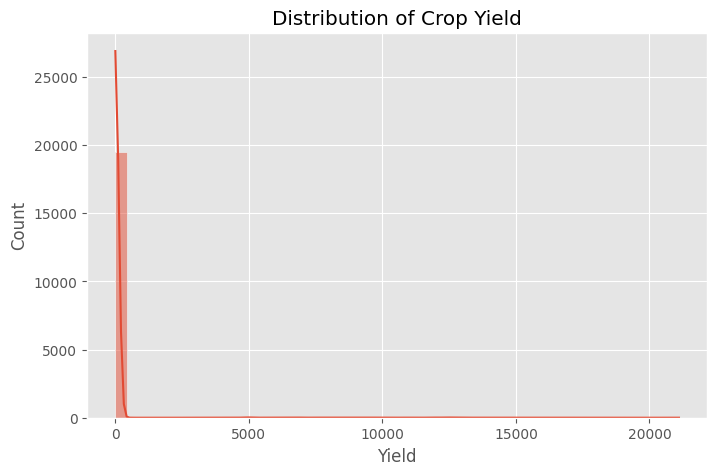

In [156]:
plt.figure(figsize=(8,5))

sns.histplot(
    merged["Yield"],
    bins=50,
    kde=True
)

plt.title("Distribution of Crop Yield")
plt.show()

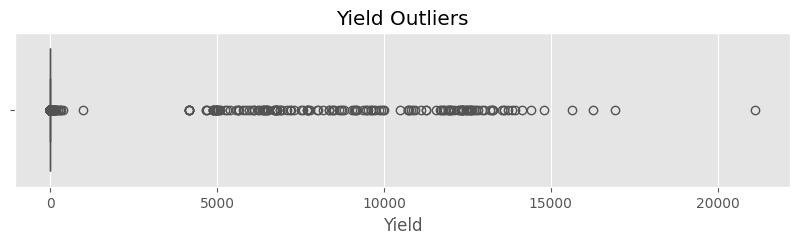

In [157]:
plt.figure(figsize=(10,2))

sns.boxplot(
    x=merged["Yield"]
)

plt.title("Yield Outliers")
plt.show()

# Section 6 - Train Validation Test Split

In [158]:
from sklearn.model_selection import train_test_split

train_df, temp_df = train_test_split(
    merged,
    test_size=0.30,
    random_state=42
)

print("Training Set :", train_df.shape)
print("Temporary Set :", temp_df.shape)

Training Set : (13782, 16)
Temporary Set : (5907, 16)


In [159]:
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=42
)

print("Validation Set :", val_df.shape)
print("Testing Set :", test_df.shape)

Validation Set : (2953, 16)
Testing Set : (2954, 16)


In [160]:
print(train_df.index.intersection(val_df.index).shape[0])
print(train_df.index.intersection(test_df.index).shape[0])
print(val_df.index.intersection(test_df.index).shape[0])

0
0
0


# Section 7- Feature Selection

In [161]:
X_train = train_df.drop(columns=["Yield", "Production"])
y_train = train_df["Yield"]

In [162]:
X_val = val_df.drop(columns=["Yield", "Production"])
y_val = val_df["Yield"]

In [163]:
X_test = test_df.drop(columns=["Yield", "Production"])
y_test = test_df["Yield"]

In [164]:
print(X_train.shape)
print(y_train.shape)

print(X_val.shape)
print(y_val.shape)

print(X_test.shape)
print(y_test.shape)

(13782, 14)
(13782,)
(2953, 14)
(2953,)
(2954, 14)
(2954,)


# Section 8– Encoding Categorical Features

In [165]:
X_train.dtypes

,0
Crop,object
year,int64
Season,object
state,object
Area,float64
Fertilizer,float64
Pesticide,float64
avg_temp_c,float64
total_rainfall_mm,float64
avg_humidity_percent,float64


In [166]:
from sklearn.preprocessing import LabelEncoder

In [167]:
crop_encoder = LabelEncoder()
season_encoder = LabelEncoder()
state_encoder = LabelEncoder()

In [168]:
X_train["Crop"] = crop_encoder.fit_transform(X_train["Crop"])

X_train["Season"] = season_encoder.fit_transform(X_train["Season"])

X_train["state"] = state_encoder.fit_transform(X_train["state"])

In [169]:
X_val["Crop"] = crop_encoder.transform(X_val["Crop"])
X_val["Season"] = season_encoder.transform(X_val["Season"])
X_val["state"] = state_encoder.transform(X_val["state"])

In [170]:
X_val.head()

,Crop,year,Season,state,Area,Fertilizer,Pesticide,avg_temp_c,total_rainfall_mm,avg_humidity_percent,N,P,K,pH
5900,48,2019,4,2,4926.0,8.460898e+05,1822.62,23.09,2368.95,78.30,60,18,38,5.8
9452,52,2005,1,9,11267.0,1.351139e+06,2366.07,20.99,916.17,47.53,60,20,40,6.0
6932,40,1999,5,20,3423000.0,3.632830e+08,924210.00,26.20,1304.31,72.99,67,26,32,6.3
2055,24,2006,1,2,18657.0,2.382685e+06,4104.54,22.91,1531.41,75.46,60,18,38,5.8
13651,52,2014,1,3,15725.0,2.373846e+06,5189.25,25.72,1115.00,58.08,85,30,25,7.2


In [171]:
X_test["Crop"] = crop_encoder.transform(X_test["Crop"])

X_test["Season"] = season_encoder.transform(X_test["Season"])

X_test["state"] = state_encoder.transform(X_test["state"])

In [172]:
X_train.head()

,Crop,year,Season,state,Area,Fertilizer,Pesticide,avg_temp_c,total_rainfall_mm,avg_humidity_percent,N,P,K,pH
13103,31,2013,2,4,87.0,12570.63,23.49,25.85,1643.60,63.20,70,35,20,6.5
17880,28,2009,1,10,2806.0,437230.92,477.02,9.04,557.76,51.57,70,25,42,6.7
14990,34,2016,2,14,29000.0,4444250.00,10150.00,25.45,1563.81,51.96,70,40,20,7.4
11147,34,2009,2,15,99100.0,15441762.00,16847.00,27.21,2277.28,66.66,75,43,26,7.1
8019,40,2002,1,8,905651.0,85737980.17,226412.75,25.39,688.83,37.91,130,48,35,7.9


In [173]:
print(X_train.dtypes)

Crop                      int64
year                      int64
Season                    int64
state                     int64
Area                    float64
Fertilizer              float64
Pesticide               float64
avg_temp_c              float64
total_rainfall_mm       float64
avg_humidity_percent    float64
N                         int64
P                         int64
K                         int64
pH                      float64
dtype: object


# Section 9- Exploratory Data Analysis (EDA)

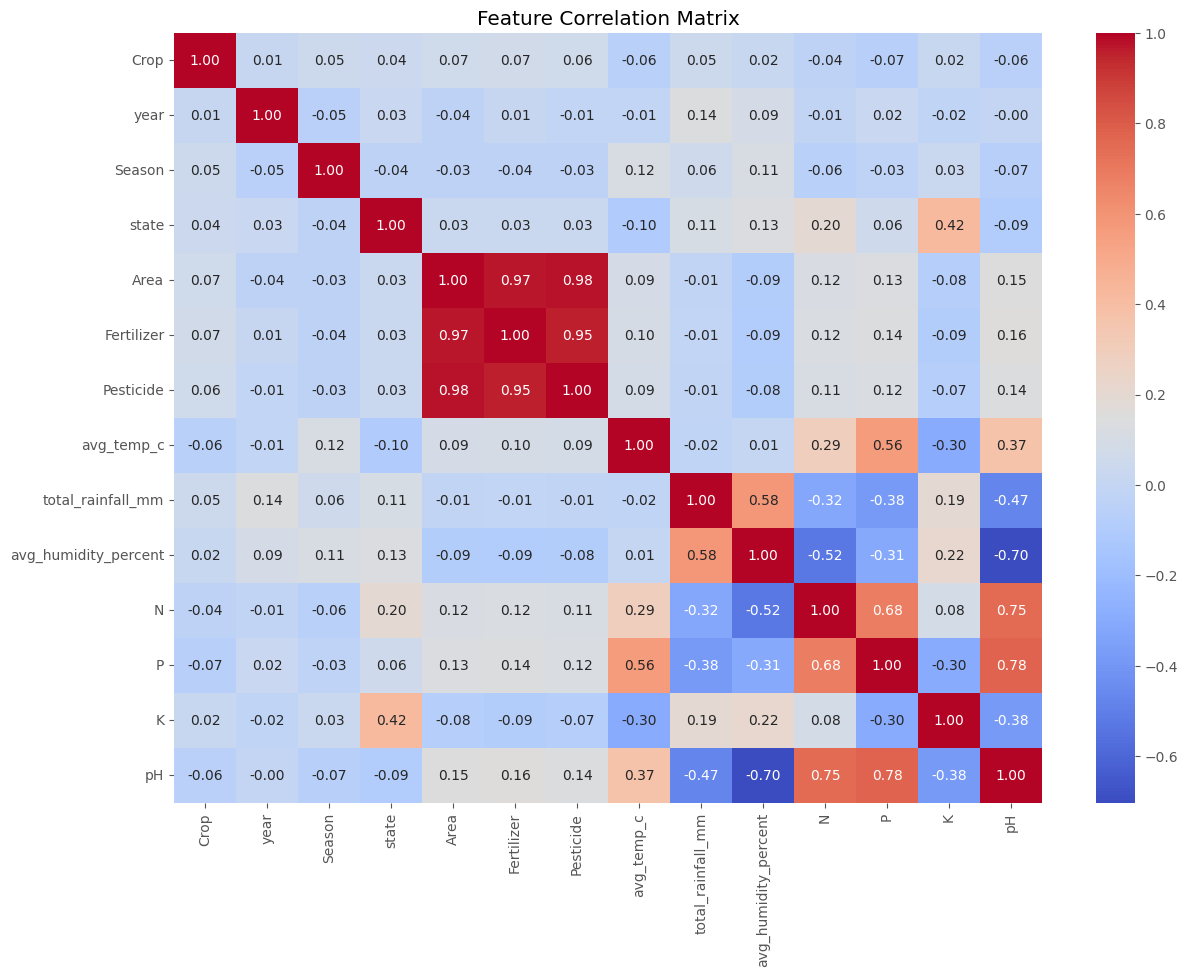

In [174]:
#Correlation Matrix
plt.figure(figsize=(14,10))

sns.heatmap(
    X_train.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Feature Correlation Matrix")
plt.show()

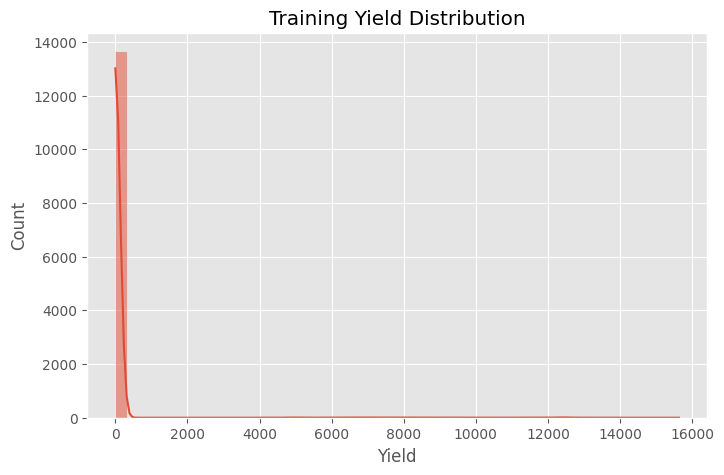

In [175]:
#Yield Distribution
plt.figure(figsize=(8,5))

sns.histplot(
    y_train,
    bins=50,
    kde=True
)

plt.title("Training Yield Distribution")
plt.show()

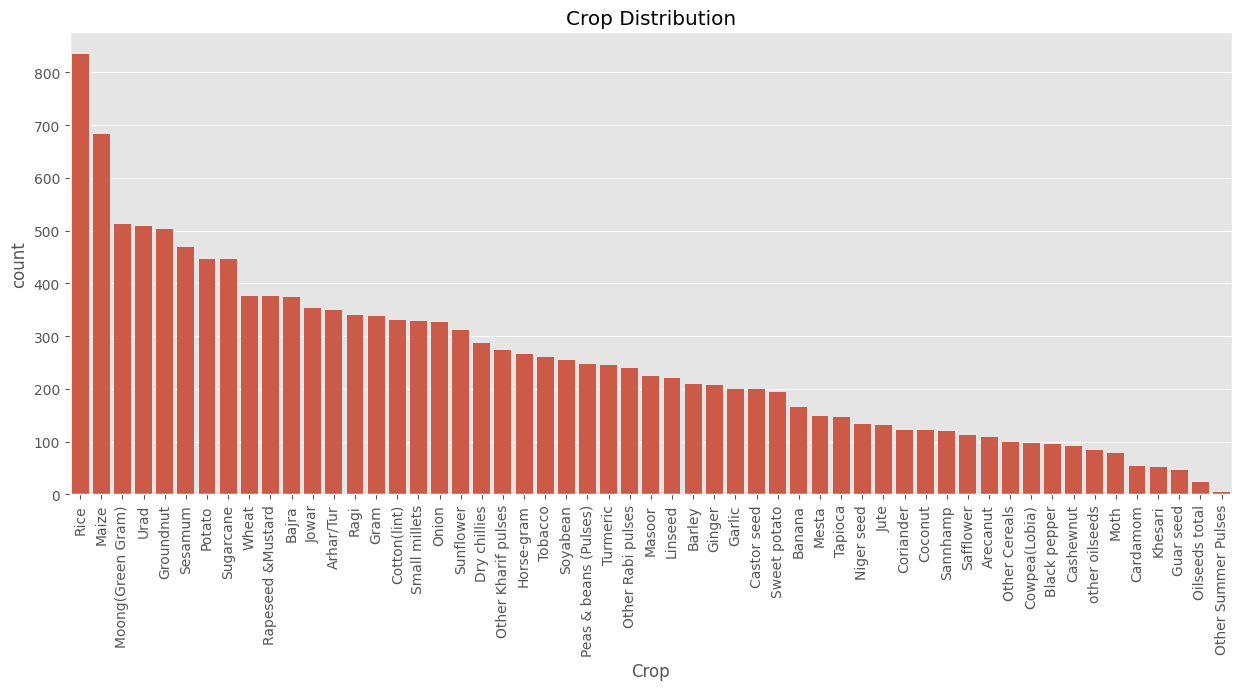

In [176]:
#Crop Distribution
plt.figure(figsize=(15,6))

sns.countplot(
    x=train_df["Crop"],
    order=train_df["Crop"].value_counts().index
)

plt.xticks(rotation=90)

plt.title("Crop Distribution")

plt.show()

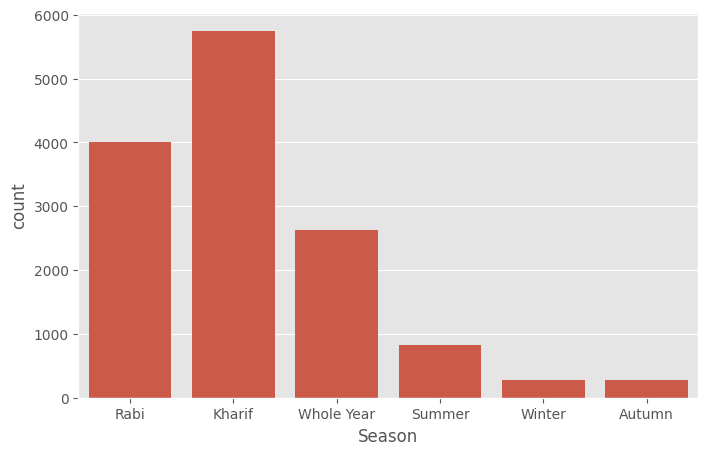

In [177]:
#Season Distribution
plt.figure(figsize=(8,5))

sns.countplot(
    x=train_df["Season"]
)

plt.show()

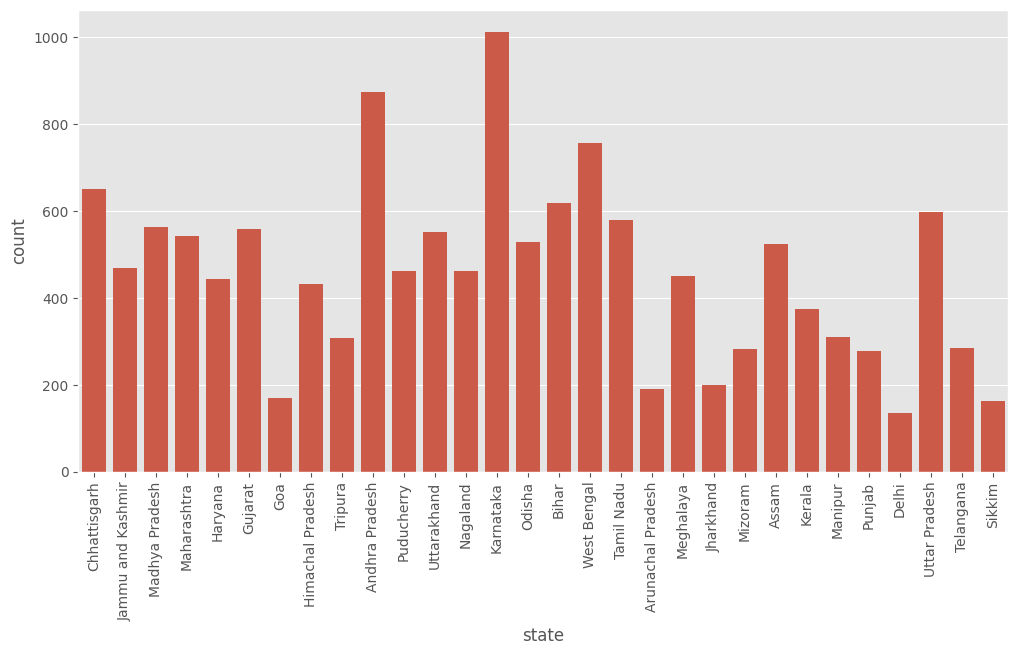

In [178]:
#State Distribution
plt.figure(figsize=(12,6))

sns.countplot(
    x=train_df["state"]
)

plt.xticks(rotation=90)

plt.show()

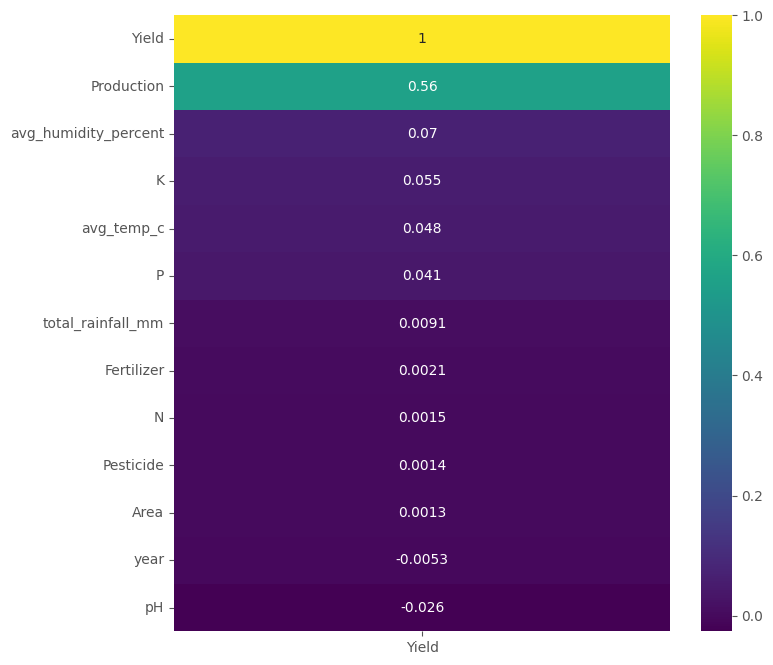

In [179]:
#Feature Correlation with Yield
corr = train_df.select_dtypes(include="number").corr()

plt.figure(figsize=(8,8))

sns.heatmap(
    corr[["Yield"]].sort_values(by="Yield", ascending=False),
    annot=True,
    cmap="viridis"
)

plt.show()

# Section 10- Model Building

In [180]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import ExtraTreesRegressor

from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)

import numpy as np

In [181]:
results = []

In [182]:
#Evaluation Function
def evaluate_model(model, model_name):

    # Train model
    model.fit(X_train, y_train)

    # Predictions
    train_pred = model.predict(X_train)
    val_pred = model.predict(X_val)
    test_pred = model.predict(X_test)

    # Metrics
    train_r2 = r2_score(y_train, train_pred)
    val_r2 = r2_score(y_val, val_pred)
    test_r2 = r2_score(y_test, test_pred)

    train_mae = mean_absolute_error(y_train, train_pred)
    val_mae = mean_absolute_error(y_val, val_pred)
    test_mae = mean_absolute_error(y_test, test_pred)

    train_rmse = np.sqrt(mean_squared_error(y_train, train_pred))
    val_rmse = np.sqrt(mean_squared_error(y_val, val_pred))
    test_rmse = np.sqrt(mean_squared_error(y_test, test_pred))

    results.append([
        model_name,
        train_r2,
        val_r2,
        test_r2,
        train_mae,
        val_mae,
        test_mae,
        train_rmse,
        val_rmse,
        test_rmse
    ])

    print(f"{model_name} Completed")

In [183]:
#Decision Tree
decision_tree = DecisionTreeRegressor(
    random_state=42
)

evaluate_model(
    decision_tree,
    "Decision Tree"
)

Decision Tree Completed


In [184]:
#Results Table
results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Train R2",
        "Validation R2",
        "Test R2",
        "Train MAE",
        "Validation MAE",
        "Test MAE",
        "Train RMSE",
        "Validation RMSE",
        "Test RMSE"
    ]
)

results_df

,Model,Train R2,Validation R2,Test R2,Train MAE,Validation MAE,Test MAE,Train RMSE,Validation RMSE,Test RMSE
0,Decision Tree,1.0,0.976466,0.925371,3.625021e-20,7.534082,13.659224,1.831343e-18,129.514272,250.559574


In [185]:
print(X_train.columns.tolist())

['Crop', 'year', 'Season', 'state', 'Area', 'Fertilizer', 'Pesticide', 'avg_temp_c', 'total_rainfall_mm', 'avg_humidity_percent', 'N', 'P', 'K', 'pH']


# Section 11- Ensemble Model Training

In [186]:
!pip install xgboost lightgbm catboost -q

In [187]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import ExtraTreesRegressor

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

In [188]:
#Random Forest
random_forest = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

evaluate_model(random_forest, "Random Forest")

Random Forest Completed


In [189]:
#Extra Trees
extra_trees = ExtraTreesRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

evaluate_model(extra_trees, "Extra Trees")

Extra Trees Completed


In [190]:
#XGBoost
xgb = XGBRegressor(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=8,
    random_state=42
)

evaluate_model(xgb, "XGBoost")

XGBoost Completed


In [191]:
#LightGBM
lgbm = LGBMRegressor(
    n_estimators=200,
    random_state=42
)

evaluate_model(lgbm, "LightGBM")

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.007621 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1720
[LightGBM] [Info] Number of data points in the train set: 13782, number of used features: 14
[LightGBM] [Info] Start training from score 81.549895
LightGBM Completed


In [192]:
#CatBoost
cat = CatBoostRegressor(
    iterations=200,
    random_state=42,
    verbose=0
)

evaluate_model(cat, "CatBoost")

CatBoost Completed


In [193]:
#Compare Models
results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Train R2",
        "Validation R2",
        "Test R2",
        "Train MAE",
        "Validation MAE",
        "Test MAE",
        "Train RMSE",
        "Validation RMSE",
        "Test RMSE"
    ]
)

results_df = results_df.sort_values(
    by="Test R2",
    ascending=False
)

results_df

,Model,Train R2,Validation R2,Test R2,Train MAE,Validation MAE,Test MAE,Train RMSE,Validation RMSE,Test RMSE
1,Random Forest,0.997722,0.977333,0.953980,2.995579e+00,7.520757,12.887013,4.185292e+01,127.105978,196.756178
3,XGBoost,0.999997,0.972873,0.929314,5.867250e-01,9.285308,14.793268,1.491380e+00,139.050903,243.850817
0,Decision Tree,1.000000,0.976466,0.925371,3.625021e-20,7.534082,13.659224,1.831343e-18,129.514272,250.559574
5,CatBoost,0.999347,0.978937,0.851992,4.767862e+00,10.707328,20.623029,2.240165e+01,122.525780,352.857804
4,LightGBM,0.996838,0.978805,0.811859,9.129116e+00,14.491248,26.352675,4.930618e+01,122.910293,397.830568
2,Extra Trees,1.000000,0.979018,0.802986,1.890251e-13,8.430303,19.619733,2.359324e-12,122.292046,407.104066


# Section 12- Hyperparameter Tuning

In [194]:
from sklearn.model_selection import RandomizedSearchCV

In [195]:
rf_params = {
    "n_estimators":[200,300,400,500],
    "max_depth":[10,20,30,None],
    "min_samples_split":[2,5,10],
    "min_samples_leaf":[1,2,4],
    "max_features":["sqrt","log2"]
}

In [196]:
rf_search = RandomizedSearchCV(
    RandomForestRegressor(random_state=42),
    rf_params,
    n_iter=20,
    cv=5,
    scoring="r2",
    random_state=42,
    n_jobs=-1
)

In [197]:
rf_search.fit(X_train, y_train)

RandomizedSearchCV(cv=5, estimator=RandomForestRegressor(random_state=42),
                   n_iter=20, n_jobs=-1,
                   param_distributions={'max_depth': [10, 20, 30, None],
                                        'max_features': ['sqrt', 'log2'],
                                        'min_samples_leaf': [1, 2, 4],
                                        'min_samples_split': [2, 5, 10],
                                        'n_estimators': [200, 300, 400, 500]},
                   random_state=42, scoring='r2')

In [198]:
print(rf_search.best_params_)

{'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': None}


In [199]:
best_rf = rf_search.best_estimator_

evaluate_model(
    best_rf,
    "Tuned Random Forest"
)

Tuned Random Forest Completed


In [200]:
results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Train R2",
        "Validation R2",
        "Test R2",
        "Train MAE",
        "Validation MAE",
        "Test MAE",
        "Train RMSE",
        "Validation RMSE",
        "Test RMSE"
    ]
)

results_df.sort_values(
    "Test R2",
    ascending=False
)

,Model,Train R2,Validation R2,Test R2,Train MAE,Validation MAE,Test MAE,Train RMSE,Validation RMSE,Test RMSE
1,Random Forest,0.997722,0.977333,0.953980,2.995579e+00,7.520757,12.887013,4.185292e+01,127.105978,196.756178
3,XGBoost,0.999997,0.972873,0.929314,5.867250e-01,9.285308,14.793268,1.491380e+00,139.050903,243.850817
0,Decision Tree,1.000000,0.976466,0.925371,3.625021e-20,7.534082,13.659224,1.831343e-18,129.514272,250.559574
5,CatBoost,0.999347,0.978937,0.851992,4.767862e+00,10.707328,20.623029,2.240165e+01,122.525780,352.857804
4,LightGBM,0.996838,0.978805,0.811859,9.129116e+00,14.491248,26.352675,4.930618e+01,122.910293,397.830568
2,Extra Trees,1.000000,0.979018,0.802986,1.890251e-13,8.430303,19.619733,2.359324e-12,122.292046,407.104066
6,Tuned Random Forest,0.991637,0.930775,0.711393,8.783882e+00,22.466330,37.835120,8.019383e+01,222.128645,492.731205


# Section 13- Feature Importance Analysis

In [201]:
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": random_forest.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance

,Feature,Importance
0,Crop,0.858872
10,N,0.096455
6,Pesticide,0.009342
1,year,0.007614
5,Fertilizer,0.007056
4,Area,0.006651
9,avg_humidity_percent,0.004524
7,avg_temp_c,0.003347
8,total_rainfall_mm,0.002655
12,K,0.001898


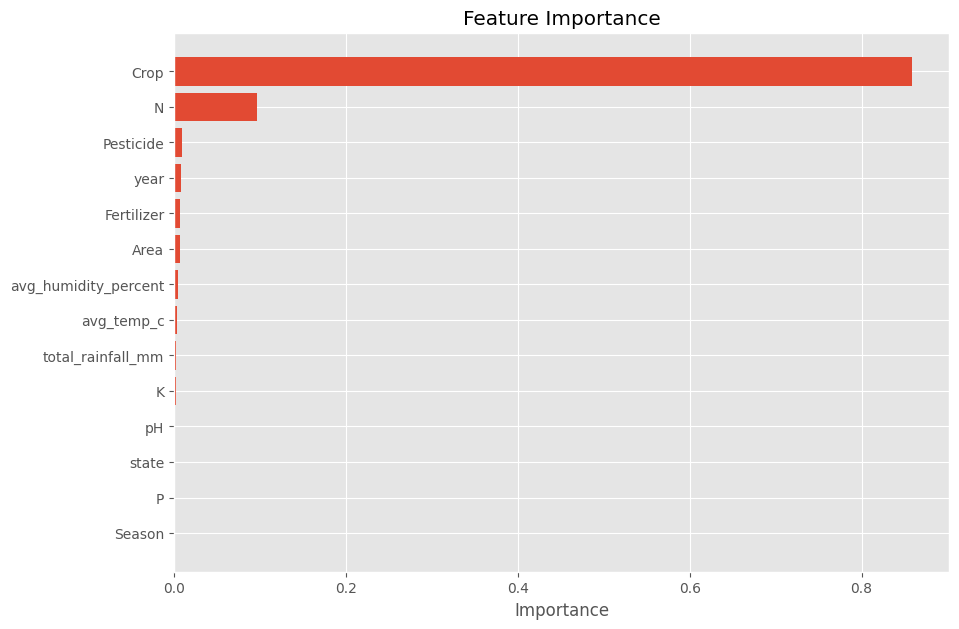

In [202]:
plt.figure(figsize=(10,7))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.title("Feature Importance")

plt.xlabel("Importance")

plt.gca().invert_yaxis()

plt.show()

In [203]:
import joblib

joblib.dump(random_forest, "crop_yield_model.pkl")

joblib.dump(crop_encoder, "crop_encoder.pkl")
joblib.dump(season_encoder, "season_encoder.pkl")
joblib.dump(state_encoder, "state_encoder.pkl")

['state_encoder.pkl']

# Section 14- Model Comparison

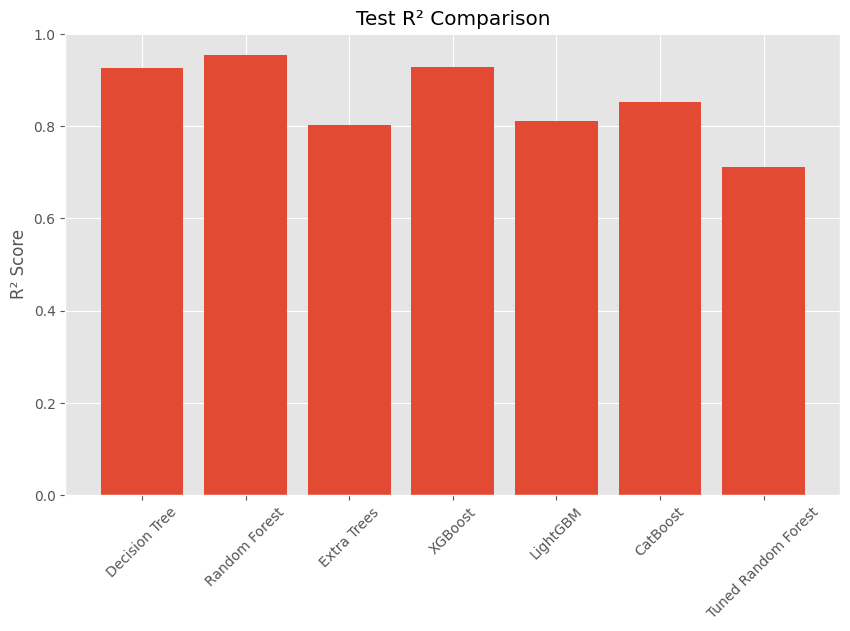

In [204]:
#R² Comparison
plt.figure(figsize=(10,6))

plt.bar(results_df["Model"], results_df["Test R2"])

plt.title("Test R² Comparison")

plt.ylabel("R² Score")

plt.xticks(rotation=45)

plt.show()

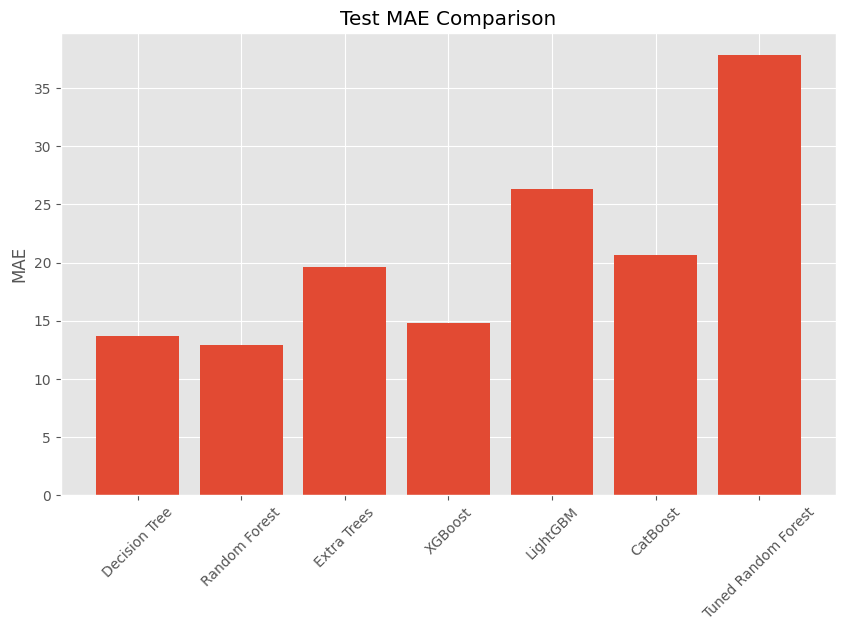

In [205]:
#MAE Comparison
plt.figure(figsize=(10,6))

plt.bar(results_df["Model"], results_df["Test MAE"])

plt.title("Test MAE Comparison")

plt.ylabel("MAE")

plt.xticks(rotation=45)

plt.show()

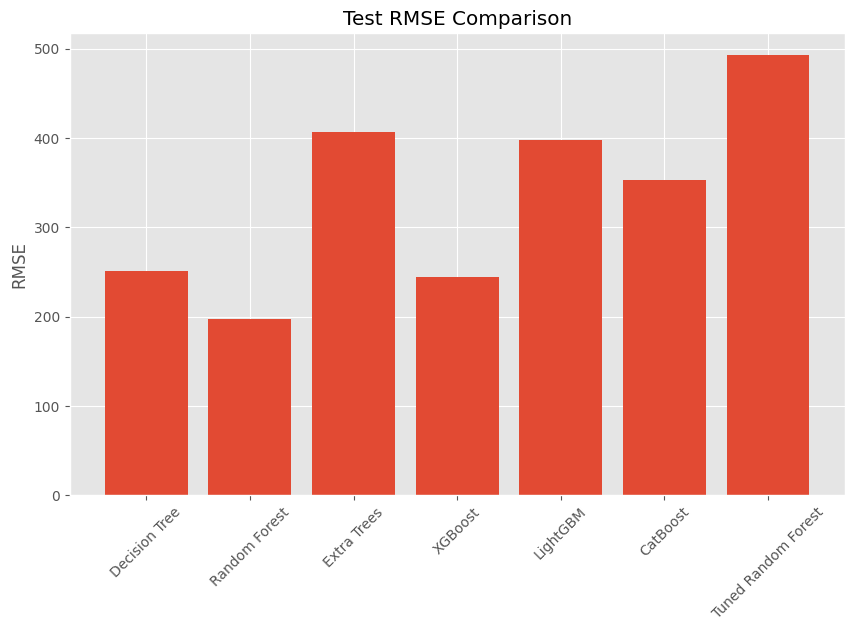

In [206]:
#RMSE Comparison
plt.figure(figsize=(10,6))

plt.bar(results_df["Model"], results_df["Test RMSE"])

plt.title("Test RMSE Comparison")

plt.ylabel("RMSE")

plt.xticks(rotation=45)

plt.show()

# Section 15- Prediction on New Data

In [210]:
def predict_crop_yield(
    crop,year,season,state,area,fertilizer,pesticide,temp,rainfall,humidity,N,P,K,pH
):

    data = pd.DataFrame({
        "Crop": [crop.strip()],
        "year": [year],
        "Season": [season.strip()],
        "state": [state.strip()],
        "Area": [area],
        "Fertilizer": [fertilizer],
        "Pesticide": [pesticide],
        "avg_temp_c": [temp],
        "total_rainfall_mm": [rainfall],
        "avg_humidity_percent": [humidity],
        "N": [N],
        "P": [P],
        "K": [K],
        "pH": [pH]
    })

    # Encode categorical values
    data["Crop"] = crop_encoder.transform(data["Crop"])
    data["Season"] = season_encoder.transform(data["Season"])
    data["state"] = state_encoder.transform(data["state"])

    # Predict
    prediction = random_forest.predict(data)

    return float(prediction[0])

In [212]:
# Example Input

crop = "Rice"
year = 2021
season = "Kharif"
state = "Punjab"

area = 1000
fertilizer = 450000
pesticide = 3500

temp = 28
rainfall = 1200
humidity = 70

N = 90
P = 40
K = 40
pH = 6.8

# Predict Yield

predicted_yield = predict_crop_yield(
    crop,year,season,state,area,fertilizer,pesticide,temp,rainfall,humidity,N,P,K,pH
)

In [215]:
print("="*65)
print("🌾 SMART CROP YIELD PREDICTION SYSTEM")
print("="*65)

print("\n📥 INPUT DETAILS")
print("-"*65)

print(f"🌱 Crop                : {crop}")
print(f"📍 State               : {state}")
print(f"🌦️ Season              : {season}")
print(f"📅 Year                : {year}")

print(f"🌾 Farm Area           : {area} hectares")
print(f"🧪 Fertilizer Used     : {fertilizer:.2f} kg")
print(f"🐛 Pesticide Used      : {pesticide:.2f} litres (L)")

print(f"\n🌡️ Temperature         : {temp} °C")
print(f"🌧️ Rainfall            : {rainfall} mm")
print(f"💧 Humidity            : {humidity} %")

print(f"\n🌱 Nitrogen (N)        : {N}")
print(f"🌱 Phosphorus (P)      : {P}")
print(f"🌱 Potassium (K)       : {K}")
print(f"⚗️ Soil pH             : {pH}")

print("\n" + "="*65)

print(f"✅ PREDICTED CROP YIELD : {predicted_yield:.2f} tonnes/hectare")

print("="*65)

print("\n📋 AI RECOMMENDATIONS")

# Rainfall
if rainfall < 800:
    print("💧 Rainfall is low. Irrigation is recommended.")
elif rainfall > 2000:
    print("🌧️ Heavy rainfall may reduce crop productivity.")
else:
    print("✅ Rainfall is suitable for cultivation.")

# Soil pH
if pH < 6:
    print("⚠️ Soil is acidic. Lime treatment is recommended.")
elif pH > 7.5:
    print("⚠️ Soil is alkaline. Soil conditioning is recommended.")
else:
    print("✅ Soil pH is within the ideal range.")

# Nitrogen
if N < 60:
    print("🌱 Nitrogen level is low. Apply nitrogen fertilizer.")
else:
    print("✅ Nitrogen level is sufficient.")

# Humidity
if humidity > 80:
    print("⚠️ High humidity may increase disease risk.")
else:
    print("✅ Humidity level is suitable.")

# Temperature
if temp < 15:
    print("❄️ Temperature is quite low for many crops.")
elif temp > 35:
    print("🔥 High temperature may stress the crop.")
else:
    print("✅ Temperature is favorable.")

print("\n📊 YIELD STATUS")

if predicted_yield < 2:
    print("🔴 Low Expected Yield")
elif predicted_yield < 4:
    print("🟡 Moderate Expected Yield")
else:
    print("🟢 High Expected Yield")

print("\n🎯 Model Used : Random Forest Regressor")
print("📈 Test R² Score : 0.954")

print("="*65)

🌾 SMART CROP YIELD PREDICTION SYSTEM

📥 INPUT DETAILS
-----------------------------------------------------------------
🌱 Crop                : Rice
📍 State               : Punjab
🌦️ Season              : Kharif
📅 Year                : 2021
🌾 Farm Area           : 1000 hectares
🧪 Fertilizer Used     : 450000.00 kg
🐛 Pesticide Used      : 3500.00 litres (L)

🌡️ Temperature         : 28 °C
🌧️ Rainfall            : 1200 mm
💧 Humidity            : 70 %

🌱 Nitrogen (N)        : 90
🌱 Phosphorus (P)      : 40
🌱 Potassium (K)       : 40
⚗️ Soil pH             : 6.8

✅ PREDICTED CROP YIELD : 4.30 tonnes/hectare

📋 AI RECOMMENDATIONS
✅ Rainfall is suitable for cultivation.
✅ Soil pH is within the ideal range.
✅ Nitrogen level is sufficient.
✅ Humidity level is suitable.
✅ Temperature is favorable.

📊 YIELD STATUS
🟢 High Expected Yield

🎯 Model Used : Random Forest Regressor
📈 Test R² Score : 0.954
